[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **BONE SURGERY DETECTION**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

# Bone Surgery Detection (YOLO11)

## Project Overview  
This project leverages **YOLO11** to build a high-precision, real-time detection and segmentation system for orthopedic surgical instruments.  
It is designed for dynamic Operating Room (OR) environments where tools frequently move, overlap, and get partially occluded.

The dataset was prepared using the **Labellerr Video Annotation Tool**, enabling:

- **Temporal Consistency**  
  Ensures stable detection across frames, even when instruments are partially hidden by tissue or fluids.

- **Interpolation**  
  Speeds up annotation by tracking moving tools like drill bits and scalpels across frames.

- **Instance Segmentation**  
  Accurately captures complex tool shapes such as retractors and rongeurs at pixel level.

---

## Real-World Applications  

### Automated Surgical Count (Safety)  
Tracks tools entering and exiting the surgical field to prevent retained surgical items (RSI).

### Surgical Workflow Analytics  
Identifies tool transitions to automatically map and analyze different phases of surgery.

### Surgeon Training & Assistance  
Provides real-time guidance and step-based prompts to support junior surgeons during procedures.

### Robotic Surgery Integration  
Enables robotic systems to detect and avoid human-held instruments in shared surgical environments.

---

## Key Value  

- Improves patient safety  
- Enhances surgical efficiency  
- Supports training and standardization  
- Enables human-robot collaboration in operating rooms  

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 



## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.


In [1]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


In [2]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


**What it does**: Imports the conversion function that transforms annotated video data into YOLO-compatible segmentation format.

---

### Convert Annotations to YOLO Segmentation Format

This cell performs the actual conversion of video annotations to YOLO format and splits the dataset into train, validation, and test sets.


In [ ]:
ANNOTATION_FILE = "annotations.json"
VIDEOS_DIRECTORY = "new_video"
OUTPUT_DATASET_DIR = "yolo_dataset_2"


convert_to_yolo_segmentation(
    annotation_path=ANNOTATION_FILE,
    videos_dir=VIDEOS_DIRECTORY,
    use_split=True,
    split_ratio=(0.7, 0.2, 0.1),
    output_dir=OUTPUT_DATASET_DIR
)

Conversion complete. Stats: {'train': 20, 'val': 5, 'test': 0}


{'stats': {'train': 20, 'val': 5, 'test': 0}, 'output_dir': 'yolos_Dataset'}

# Load and Train YOLO Segmentation Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
# Initialize the Extra Large model
from ultralytics import YOLO


model = YOLO('yolo11l-seg.pt') 

results = model.train(
    data='/kaggle/working/mdata.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    project='/kaggle/working/newpatient',
    name='train_run_7',
    device=0,   # 50% chance to flip upside-down
)

# YOLOv11 Instance Segmentation: Single Frame Inference
 
This script performs **single-frame inference** using a custom-trained YOLOv11 segmentation model.  
It extracts a specific frame from a video and applies instance segmentation to verify the predictions.


0: 384x640 4 Bones, 2 Bone Holding Forcepss, 1 Bone Screw, 1 Hohmann Retractor, 1 Self-Retaining Retractor, 1598.0ms
Speed: 8.2ms preprocess, 1598.0ms inference, 127.6ms postprocess per image at shape (1, 3, 384, 640)


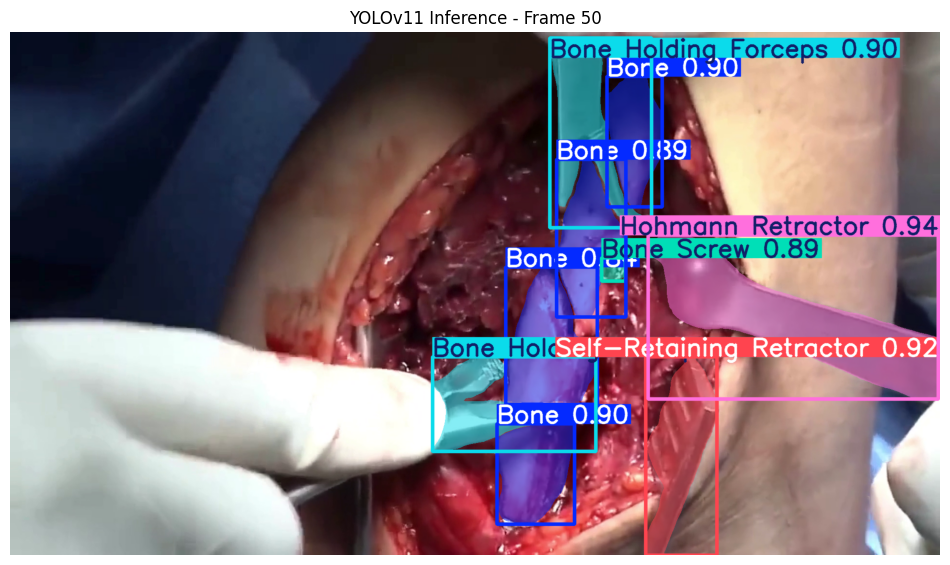

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load your custom trained waste model
model = YOLO('best.pt') 

# 2. Path to your video file
video_path = 'Untitled design (17).mp4'
cap = cv2.VideoCapture(video_path)

# 3. Jump to the 700th frame
frame_no = 50
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
success, frame = cap.read()

if success:
    # 4. Run inference
    results = model.predict(
        source=frame, 
        conf=0.7,
        retina_masks=True,
        show_boxes=False,
        show_labels=True
    )

    # 5. Get the annotated frame (OpenCV uses BGR)
    annotated_frame = results[0].plot()

    # 6. Convert BGR to RGB for Matplotlib (OpenCV colors are swapped)
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    # 7. Display directly in VS Code output
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')  # Hide the X and Y axis numbers
    plt.title(f"YOLOv11 Inference - Frame {frame_no}")
    plt.show()
    
else:
    print(f"Error: Frame {frame_no} not found.")

cap.release()

# Script Deep Dive: Bone Surgery Inference

## 1. Model Loading & Weights  
The script loads `weights/best.pt` from the training runs.  
In medical applications like bone surgery detection, selecting the **best-performing weights** is critical, as they represent the highest **Mean Average Precision (mAP)** achieved on the validation set without overfitting.

---

## 2. Optimized Prediction Parameters  

- **`conf = 0.3`**  
  A balanced confidence threshold.  
  In surgical environments, it is safer to allow a few false positives rather than risk false negatives (missing a critical instrument).

- **`retina_masks = True`**  
  Enables high-resolution segmentation masks.  
  This ensures fine details—such as the tips of scalpels or retractor edges—are accurately captured.

- **`line_width = 2`**  
  Uses thinner visualization lines to avoid clutter.  
  This keeps the surgical field clear and unobstructed for better visibility.

---

## 3. Stream Processing  

- **`stream = True`**  
  Processes the video frame-by-frame as a generator.  

  Benefits:
  - Prevents memory overflow (OOM errors)  
  - Handles long surgical videos efficiently  
  - Suitable for production-level deployment  

---

## Technical Insight  

This configuration balances:
- **Accuracy (high-quality segmentation)**  
- **Safety (low risk of missed detections)**  
- **Efficiency (memory-optimized processing)**  

Making it well-suited for real-time surgical environments.

---

In [ ]:
from ultralytics import YOLO

# 1. Load your newly trained custom model
# Make sure "best.pt" is in the same directory, or provide the full path
model = YOLO("/kaggle/working/newpatient/train_run_82/weights/best.pt") 

video_path = "/kaggle/input/datasets/aaryanaggarwal5040/bone-surgery/Untitled design (17).mp4" # Update this to your actual video file name

print(f"Starting inference on {video_path}...")
results = model.predict(
    source=video_path,
    save=True, 
    conf=0.3,
    show_boxes=True,    # Keep this False to hide the rectangles
    show_labels=True,    # Keep this True to see the names
    show_conf=False,
    retina_masks=True,
    stream=True,
    verbose=True,
    # --- ADD THIS TO SHRINK THE TEXT ---
    line_width=2         # This will make the font significantly smaller and thinner
)

# 3. Execute the video processing loop
# Because stream=True creates a generator, we must iterate through it to process the video
for frame_result in results:
    pass 

print("\nInference complete!")
print("Look for your newly generated video inside the 'runs/segment/predict/' folder.")

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*


Q